# Notebook 4: Exploratory Data Analysis

## Objective 
The objective of this notebook is to explore the feature-engineered dataset before model development. The analysis assesses the distibutions, temporal patterns, category-level differences, and relationships between exchange-rate movements and food price indicators. The exploratory analysis is intended to identify important patterns, potential anomalies, and relationships that may inform the subsequent econometric and machine learning modelling stages.

In [910]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [911]:
# load the dataset
data = pd.read_csv(
    "../data/processed/featured_data.csv",
    parse_dates=["Date"]
)

In [912]:
# view the data
data.head()

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,...,ExchangeRate_Lag1,ExchangeRate_Lag3,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3
0,2015-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,57.2,12.452687,2015,...,12.303048,12.012553,11.566500,57.0,57.0,0.012163,0.012163,0.000000,12.241892,0.247116
1,2015-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.3,12.914595,2015,...,12.452687,11.969940,11.577440,57.2,57.3,0.037093,0.037093,0.000000,12.556777,0.318784
2,2015-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,13.610852,2015,...,12.914595,12.303048,12.068727,59.3,57.0,0.053912,0.053912,0.000000,12.992711,0.583021
3,2015-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.5,13.504323,2015,...,13.610852,12.452687,12.012553,58.9,57.2,-0.007827,0.000000,0.007827,13.343257,0.375034
4,2015-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,14.125733,2015,...,13.504323,12.914595,11.969940,59.5,59.3,0.046016,0.046016,0.000000,13.746969,0.332316


In [913]:
# inspect data
print("Shape:", data.shape)

Shape: (14150, 22)


In [914]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14150 entries, 0 to 14149
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 14150 non-null  datetime64[us]
 1   DivisionDescription  14150 non-null  str           
 2   GroupDescription     14150 non-null  str           
 3   ClassDescription     14150 non-null  str           
 4   SubclassDescription  14150 non-null  str           
 5   Weight               14150 non-null  float64       
 6   Eight digit code     14150 non-null  int64         
 7   CPI                  14150 non-null  float64       
 8   ExchangeRate         14150 non-null  float64       
 9   Year                 14150 non-null  int64         
 10  Month                14150 non-null  int64         
 11  Quarter              14150 non-null  int64         
 12  ExchangeRate_Lag1    14150 non-null  float64       
 13  ExchangeRate_Lag3    14150 non-null  float

In [915]:
data.describe()

,Date,Weight,Eight digit code,CPI,ExchangeRate,Year,Month,Quarter,ExchangeRate_Lag1,ExchangeRate_Lag3,ExchangeRate_Lag6,CPI_Lag1,CPI_Lag3,ExchangeRate_Change,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3
count,14150,14150.000000,1.415000e+04,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000,14150.000000
mean,2020-12-05 13:01:46.346289,0.144390,1.160668e+06,80.513258,15.794418,2020.459293,6.653852,2.550883,15.760464,15.681964,15.547186,80.141845,79.395081,0.002929,0.014649,0.011720,15.758757,0.369359
min,2015-07-01 00:00:00,0.010375,1.111201e+06,40.100000,11.824600,2015.000000,1.000000,1.000000,11.824600,11.824600,11.566500,40.100000,40.100000,-0.074539,0.000000,0.000000,11.915853,0.053243
25%,2018-05-01 00:00:00,0.032154,1.124004e+06,68.100000,14.091309,2018.000000,4.000000,2.000000,14.081841,14.047787,13.923768,67.700000,67.200000,-0.019830,0.000000,0.000000,14.113855,0.200526
50%,2021-01-01 00:00:00,0.089114,1.161201e+06,78.700000,15.215175,2021.000000,7.000000,3.000000,15.146414,15.062438,14.984636,78.200000,77.500000,-0.004332,0.000000,0.004332,15.231720,0.315739
75%,2023-08-01 00:00:00,0.173193,1.186001e+06,95.300000,17.836520,2023.000000,10.000000,4.000000,17.836520,17.836520,17.836520,94.900000,93.900000,0.022168,0.022168,0.019830,17.751849,0.473305
max,2025-12-01 00:00:00,1.447038,1.290001e+06,172.100000,19.065941,2025.000000,12.000000,4.000000,19.065941,19.065941,19.065941,172.100000,172.100000,0.115651,0.115651,0.074539,18.929468,1.784508
std,NaN,0.190869,3.739225e+04,15.720060,2.054620,3.021960,3.437996,1.113747,2.076117,2.117505,2.167035,15.699572,15.626240,0.033929,0.023775,0.015573,2.044655,0.247968


In [916]:
# missing values
missing_values = data.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [917]:
# date coverage 
print("Start date:", data["Date"].min())
print("End date:", data["Date"].max())

Start date: 2015-07-01 00:00:00
End date: 2025-12-01 00:00:00


In [918]:
# check observations per year
observations_per_year = (
    data.groupby(data["Date"].dt.year)
    .size()
)

observations_per_year

Date
2015     570
2016    1140
2017    1293
2018    1344
2019    1344
2020    1344
2021    1344
2022    1389
2023    1404
2024    1404
2025    1574
dtype: int64

In [919]:
# check missing values
missing_values = data.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [920]:
# duplicate observations
data.duplicated().sum()

np.int64(0)

In [921]:
data.duplicated(
    subset=["Date", "Eight digit code"]
).sum()

np.int64(0)

In [922]:
# food categories analysis
print("Number of food categories:", data["SubclassDescription"].nunique())

Number of food categories: 49


In [923]:
data["SubclassDescription"].unique()

<StringArray>
[                                                               'Cereals',
                                                       'Flour of cereals',
                                              'Bread and bakery products',
                                                      'Breakfast cereals',
                 'Macaroni, noodles, couscous and similar pasta products',
                                         'Meat, fresh, chilled or frozen',
                               'Meat , dried, salted, in brine or smoked',
                    'Offal, blood and other parts of slaughtered animals',
 'Meat, offal, blood and other parts of slaughtered animals preparations',
                                                                   'Fish',
                                                      'Fish preparations',
                                                          'Other seafood',
                                                                   'Milk',
           

In [924]:
category_counts = (
    data["SubclassDescription"]
    .value_counts()
)

category_counts.head(10)

SubclassDescription
Meat, fresh, chilled or frozen                                            1029
Bread and bakery products                                                  840
Salt, condiments and sauces                                                756
Meat, offal, blood and other parts of slaughtered animals preparations     523
Cheese                                                                     514
Other vegetables, fresh or chilled                                         514
Milk                                                                       504
Fruit-bearing vegetables, fresh or chilled                                 504
Other food products n.e.c.                                                 504
Meat , dried, salted, in brine or smoked                                   378
Name: count, dtype: int64

In [925]:
# EDA Question 1: How did the exchange rate behave during the study period?

monthly_exchange = (
    data[["Date", "ExchangeRate"]]
    .drop_duplicates()
    .sort_values("Date")
)

monthly_exchange.head()

,Date,ExchangeRate
0,2015-07-01,12.452687
1,2015-08-01,12.914595
2,2015-09-01,13.610852
3,2015-10-01,13.504323
4,2015-11-01,14.125733


In [926]:
monthly_exchange.shape

(126, 2)

In [927]:
monthly_exchange["Date"].min(), monthly_exchange["Date"].max()

(Timestamp('2015-07-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

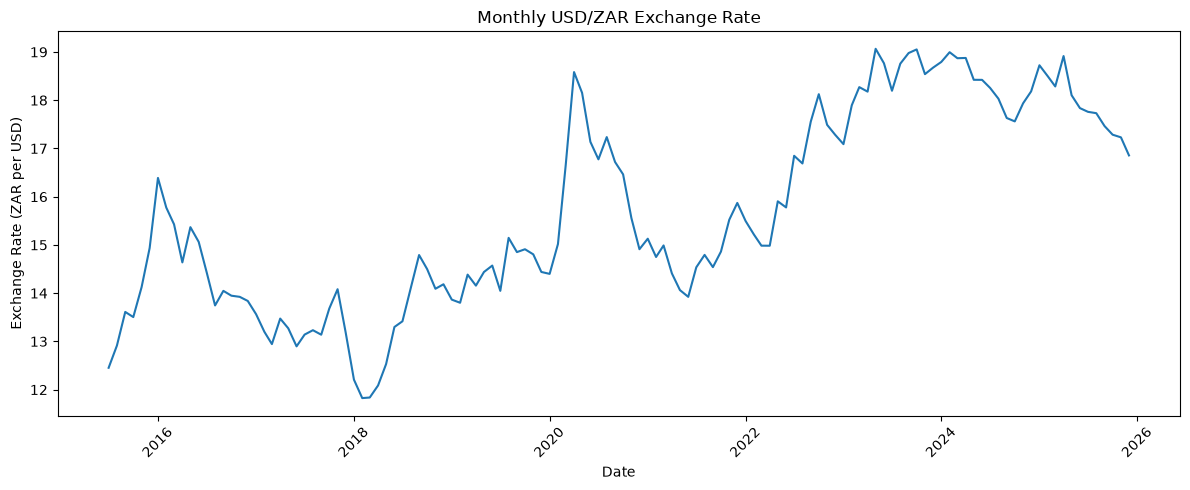

In [928]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_exchange["Date"],
    monthly_exchange["ExchangeRate"]
)
plt.title("Monthly USD/ZAR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate (ZAR per USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Visual and Calculation analysis

The USD/ZAR exchange rate displays substantial fluctuations throughout the study period rather than following a consistently increasing or decreasing trend. The highest observed exchange rate in the feature-engineered dataset occurred in May 2023 at R19.065941 per USD, while the lowest occurred in February 2018 at R11.8246 per USD.

The difference between these values indicates considerable variation in the Rand's value relative to the US Dollar during the study period. Several additional periods of exchange-rate movement are visible in the time-series plot and may need further investigation when interpreting exchange-rate pass-through to food prices.

In [929]:
# calculations
print("Exact date and exchange rate value at maximum:\n",
      monthly_exchange.loc[
     monthly_exchange["ExchangeRate"].idxmax()
])

Exact date and exchange rate value at maximum:
 Date            2023-05-01 00:00:00
ExchangeRate              19.065941
Name: 94, dtype: object


In [930]:
print("Exact date and exchange rate value at minimum:\n",
      monthly_exchange.loc[
          monthly_exchange["ExchangeRate"].idxmin()
      ]
      )

Exact date and exchange rate value at minimum:
 Date            2018-02-01 00:00:00
ExchangeRate                11.8246
Name: 31, dtype: object


In [931]:
#  EDA Question 2: How have food prices changed over the same period?

food_cpi_monthly = (
    data.groupby("Date")["CPI"]
    .mean()
    .reset_index()
)

In [932]:
food_cpi_monthly.head()

,Date,CPI
0,2015-07-01,57.486316
1,2015-08-01,58.254737
2,2015-09-01,58.181053
3,2015-10-01,58.580000
4,2015-11-01,58.867368


In [933]:
food_cpi_monthly.head()

,Date,CPI
0,2015-07-01,57.486316
1,2015-08-01,58.254737
2,2015-09-01,58.181053
3,2015-10-01,58.580000
4,2015-11-01,58.867368


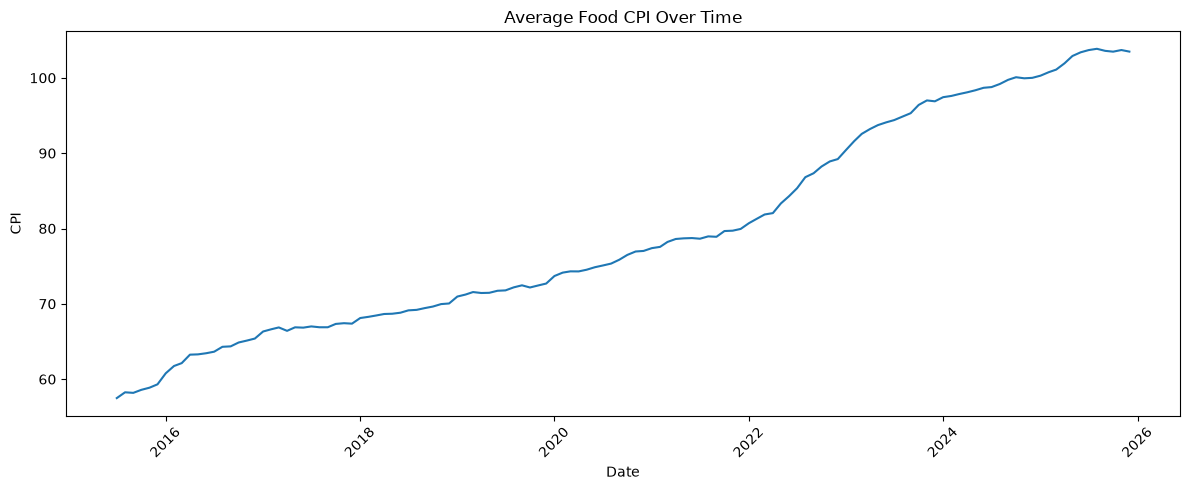

In [934]:
plt.figure(figsize=(12,5))

plt.plot(
    food_cpi_monthly["Date"],
    food_cpi_monthly["CPI"]
)

plt.title("Average Food CPI Over Time")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [935]:
# cpi investigation
data[["Date", "SubclassDescription", "CPI"]].head(10)

,Date,SubclassDescription,CPI
0,2015-07-01,Cereals,57.2
1,2015-08-01,Cereals,59.3
2,2015-09-01,Cereals,58.9
3,2015-10-01,Cereals,59.5
4,2015-11-01,Cereals,58.9
5,2015-12-01,Cereals,58.7
6,2016-01-01,Cereals,59.7
7,2016-02-01,Cereals,59.9
8,2016-03-01,Cereals,60.2
9,2016-04-01,Cereals,61.3


In [936]:
category_cpi = (
    data.groupby("SubclassDescription")["CPI"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

category_cpi.head(10)

,mean,min,max
SubclassDescription,,,
Other seafood,107.140000,105.7,108.6
Butter and other fats and oils derived from milk,102.060000,99.2,104.4
"Jams, fruit jellies, marmelades, fruit puree and paste",96.801818,80.7,106.9
"Other fruits, fresh",91.046825,73.6,120.7
"Spices, culinary herbs and seeds",89.483969,57.6,107.2
"Meat, fresh, chilled or frozen",85.935374,56.8,129.4
"Meat, offal, blood and other parts of slaughtered animals preparations",85.813958,60.3,119.4
Baby food,85.813725,61.1,106.3
Flour of cereals,85.346307,56.3,113.1


In [937]:
category_cpi.sort_values("mean").head(10)

,mean,min,max
SubclassDescription,,,
"Dates, figs and tropical fruits, fresh",69.493651,40.1,100.0
Pulses,71.129365,46.4,101.5
Eggs,71.962698,48.8,104.4
"Chocolate, cocoa, and cocoa-based food products",72.133730,45.3,107.5
Tubers,72.451984,44.8,114.9
Sugar,72.855159,42.6,103.7
Other milk and cream,74.540873,48.3,104.9
Water,75.089683,55.1,102.6
"Nut puree, nut butter and nut pastes",75.150000,50.9,101.2


In [938]:
category_cpi.sort_values("mean", ascending=False).head(10)

,mean,min,max
SubclassDescription,,,
Other seafood,107.140000,105.7,108.6
Butter and other fats and oils derived from milk,102.060000,99.2,104.4
"Jams, fruit jellies, marmelades, fruit puree and paste",96.801818,80.7,106.9
"Other fruits, fresh",91.046825,73.6,120.7
"Spices, culinary herbs and seeds",89.483969,57.6,107.2
"Meat, fresh, chilled or frozen",85.935374,56.8,129.4
"Meat, offal, blood and other parts of slaughtered animals preparations",85.813958,60.3,119.4
Baby food,85.813725,61.1,106.3
Flour of cereals,85.346307,56.3,113.1


In [939]:
data["CPI_Change"] = (
    data.groupby("Eight digit code")["CPI"]
    .pct_change()
)

In [940]:
data[["Date", "SubclassDescription", "CPI", "CPI_Change"]].head(15)

,Date,SubclassDescription,CPI,CPI_Change
0,2015-07-01,Cereals,57.2,NaN
1,2015-08-01,Cereals,59.3,0.036713
2,2015-09-01,Cereals,58.9,-0.006745
3,2015-10-01,Cereals,59.5,0.010187
4,2015-11-01,Cereals,58.9,-0.010084
5,2015-12-01,Cereals,58.7,-0.003396
6,2016-01-01,Cereals,59.7,0.017036
7,2016-02-01,Cereals,59.9,0.003350
8,2016-03-01,Cereals,60.2,0.005008
9,2016-04-01,Cereals,61.3,0.018272


In [941]:
data["CPI_Change_Pct"] = data["CPI_Change"] * 100

In [942]:
data[[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]].head(15)

,Date,SubclassDescription,CPI,CPI_Change_Pct
0,2015-07-01,Cereals,57.2,NaN
1,2015-08-01,Cereals,59.3,3.671329
2,2015-09-01,Cereals,58.9,-0.674536
3,2015-10-01,Cereals,59.5,1.018676
4,2015-11-01,Cereals,58.9,-1.008403
5,2015-12-01,Cereals,58.7,-0.339559
6,2016-01-01,Cereals,59.7,1.703578
7,2016-02-01,Cereals,59.9,0.335008
8,2016-03-01,Cereals,60.2,0.500835
9,2016-04-01,Cereals,61.3,1.827243


In [943]:
# inspect CPI changes
data["CPI_Change_Pct"].describe()

count    14016.000000
mean         0.505561
std          2.465435
min        -20.660147
25%         -0.408267
50%          0.370828
75%          1.327581
max         32.545455
Name: CPI_Change_Pct, dtype: float64

### CPI Analysis

The average monthly CPI change is approximately 0.51%, while the median is 0.37%. This means that the CPI generally increased from one month to the next across the category-month observations.


CPI: Consumer Price index, measures monthly changes in prices for a range of consumer product.

In [944]:
# extreme observations
data.loc[
    data["CPI_Change_Pct"].idxmin(),
    ["Date", "SubclassDescription", "CPI", "CPI_Change_Pct"]
]

Date                                          2015-10-01 00:00:00
SubclassDescription    Fruit-bearing vegetables, fresh or chilled
CPI                                                          64.9
CPI_Change_Pct                                         -20.660147
Name: 8140, dtype: object

In [945]:
data.loc[
    data["CPI_Change_Pct"].idxmax(),
    ["Date", "SubclassDescription", "CPI", "CPI_Change_Pct"]
]

Date                                          2016-12-01 00:00:00
SubclassDescription    Leafy or stem vegetables, fresh or chilled
CPI                                                          72.9
CPI_Change_Pct                                          32.545455
Name: 7776, dtype: object

In [946]:
# negative extreme 
data[
    (data["SubclassDescription"] == "Fruit-bearing vegetables, fresh or chilled") &
    (data["Date"].between("2015-08-01", "2015-10-01"))
][[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]]

,Date,SubclassDescription,CPI,CPI_Change_Pct
8012,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",54.2,3.041825
8013,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",55.3,2.029520
8014,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",61.9,11.934901
8138,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",81.7,30.720000
8139,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",81.8,0.122399
8140,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",64.9,-20.660147
8264,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",54.9,-2.831858
8265,2015-09-01,"Fruit-bearing vegetables, fresh or chilled",59.4,8.196721
8266,2015-10-01,"Fruit-bearing vegetables, fresh or chilled",63.9,7.575758
8390,2015-08-01,"Fruit-bearing vegetables, fresh or chilled",61.1,6.818182


In [947]:
# positive extreme
data[
    (data["SubclassDescription"] == "Leafy or stem vegetables, fresh or chilled") &
    (data["Date"].between("2016-10-01", "2016-12-01"))
][[
    "Date",
    "SubclassDescription",
    "CPI",
    "CPI_Change_Pct"
]]

,Date,SubclassDescription,CPI,CPI_Change_Pct
7648,2016-10-01,"Leafy or stem vegetables, fresh or chilled",49.9,-1.771654
7649,2016-11-01,"Leafy or stem vegetables, fresh or chilled",50.4,1.002004
7650,2016-12-01,"Leafy or stem vegetables, fresh or chilled",51.6,2.380952
7774,2016-10-01,"Leafy or stem vegetables, fresh or chilled",57.1,-2.559727
7775,2016-11-01,"Leafy or stem vegetables, fresh or chilled",55.0,-3.677758
7776,2016-12-01,"Leafy or stem vegetables, fresh or chilled",72.9,32.545455
7900,2016-10-01,"Leafy or stem vegetables, fresh or chilled",67.0,-1.759531
7901,2016-11-01,"Leafy or stem vegetables, fresh or chilled",68.6,2.388060
7902,2016-12-01,"Leafy or stem vegetables, fresh or chilled",70.3,2.478134


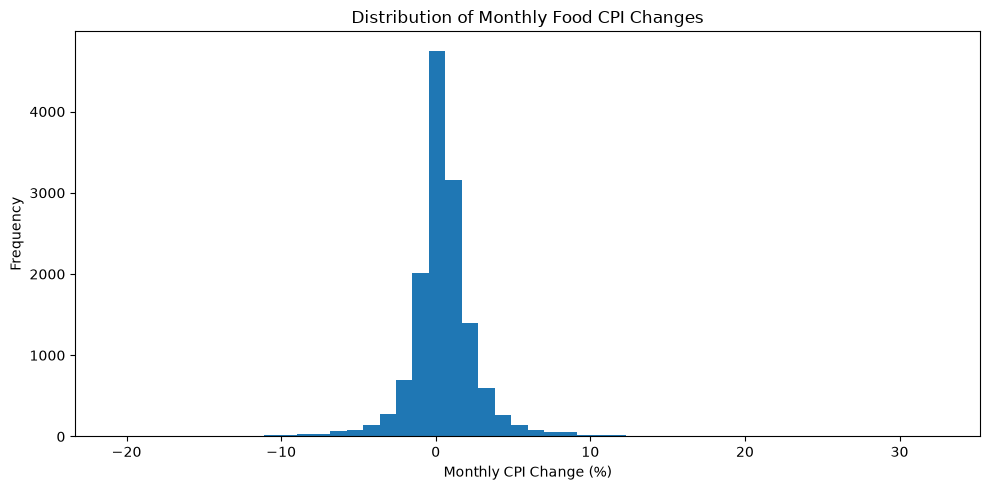

In [948]:
# EDA Question 3: how are monthly CPI changes distributed across all food items and months?
plt.figure(figsize=(10, 5))

plt.hist(
    data["CPI_Change_Pct"].dropna(),
    bins=50
)

plt.title("Distribution of Monthly Food CPI Changes")
plt.xlabel("Monthly CPI Change (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Distribution of Monthly Food CPI Changes

The distribution of monthly CPI changes is concentrated around relatively small positive and negative changes, with the majority of observations falling within the central range of approximately -12% to 13%. The distribution also contains a small number of observations with substantially larger positive and negative changes, as identified by the minimum and maximum values.

This indicates that while most food-price movements are relatively moderate at the monthly level, certain food items and periods experience considerably larger changes. These observations are retained for further investigation rather than being removed solely because they represent extreme values.

In [949]:
# calculate number of observations that positive, negative or approximately zero
positive_changes = (data["CPI_Change_Pct"] > 0).sum()
negative_changes = (data["CPI_Change_Pct"] < 0).sum()
zero_changes = (data["CPI_Change_Pct"] == 0).sum()

print("Positive changes:", positive_changes)
print("Negative changes:", negative_changes)
print("Zero changes:", zero_changes)

Positive changes: 8463
Negative changes: 4869
Zero changes: 684


In [950]:
# percentage calculations
total_changes = data["CPI_Change_Pct"].notna().sum()
print(
    "Positive:",
    round((positive_changes / total_changes) * 100, 2),
    "%"
)

print(
    "Negative:",
    round((negative_changes / total_changes) * 100, 2),
    "%"
)

print(
    "Zero:",
    round((zero_changes / total_changes) * 100, 2),
    "%"
)

Positive: 60.38 %
Negative: 34.74 %
Zero: 4.88 %


### Calculation Analysis
Out of the 14,016 non-missing category-month CPI changes, 8,463 (60.38%) were positive, 4,869 (34.74%) were negative, and 684 (4.88%) were unchanged.

The higher frequency of positive monthly CPI changes indicates that food-price increases occur more frequently than decreases across the disaggregated observations. This descriptive pattern provides useful context for the subsequent analysis of asymmetric exchange-rate pass-through. However, the frequency of price increases alone does not establish that exchange-rate movements are responsible for these changes. 

In [951]:
# Question 4: Do different food categories behave differently?

category_volatility = (
    data.groupby("SubclassDescription")["CPI_Change_Pct"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("std", ascending=False)
)

category_volatility.head(10)

,mean,std,min,max
SubclassDescription,,,,
"Fruit-bearing vegetables, fresh or chilled",0.726732,6.623252,-20.660147,31.470588
"Dates, figs and tropical fruits, fresh",0.776218,5.633144,-12.486309,20.084567
Tubers,0.638511,5.332827,-13.287402,21.302428
"Other fruits, fresh",0.124804,5.116449,-18.889809,15.410200
"Leafy or stem vegetables, fresh or chilled",0.519322,4.808853,-13.442211,32.545455
"Other vegetables, fresh or chilled",0.513281,3.781863,-16.646341,21.150442
Vegetable oils,0.580431,2.616315,-7.934132,16.046967
"Stone fruits and pome fruits, fresh",0.503984,2.456768,-8.364084,5.300000
Milk-based desserts and beverages,0.348971,2.355304,-7.002188,7.011494


### Food category Analysis 
Different food categories exhibit different degrees of monthly CPI volatility.

Volatility: how fast and how much something changes or moves up and down over time

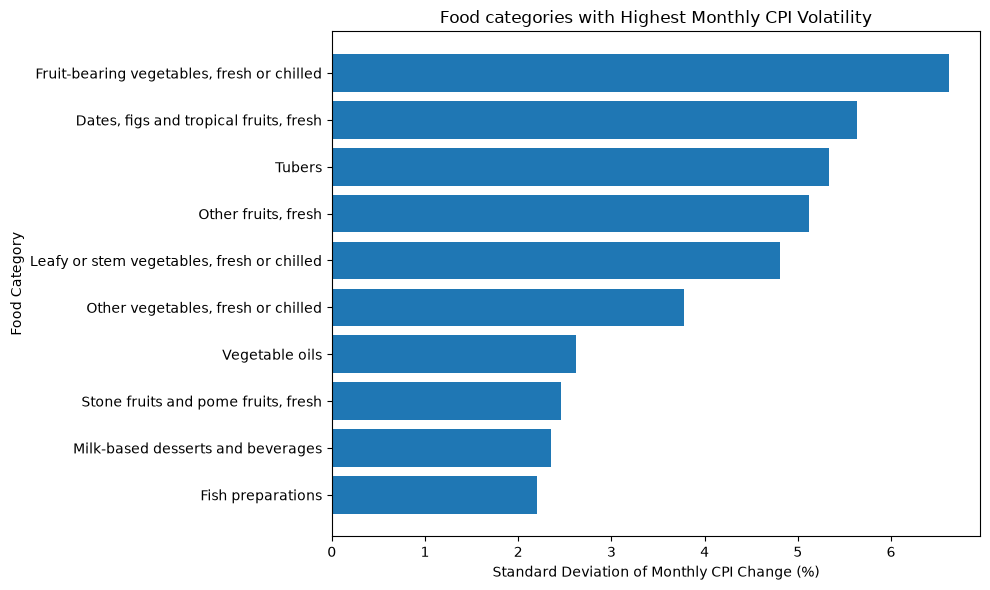

In [952]:
top_10_volatility = category_volatility.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_volatility.index[::-1],
    top_10_volatility["std"][::-1]
)

plt.title("Food categories with Highest Monthly CPI Volatility")
plt.xlabel("Standard Deviation of Monthly CPI Change (%)")
plt.ylabel("Food Category")
plt.tight_layout()
plt.show()

### Volatility Analysis
The results indicate substantial heterogeneity in monthly CPI volatility across food categories. Fruit-bearing vegetables have the highest observed standard deviation of monthly CPI changes among the categories analysed, indicating greater month-to-month variability.

In [953]:
# prepare monthly exchange-rate changes and lags
monthly_exchange = monthly_exchange.sort_values("Date").copy()

monthly_exchange["ExchangeRate_Change_Pct"] = (
    monthly_exchange["ExchangeRate"]
    .pct_change()
    .mul(100)
)

for lag in (1, 3, 6):
    monthly_exchange[f"ExchangeRate_Change_Lag{lag}_Pct"] = (
        monthly_exchange["ExchangeRate_Change_Pct"].shift(lag)
    )

In [954]:
# inspect
monthly_exchange.head(10)

,Date,ExchangeRate,ExchangeRate_Change_Pct,ExchangeRate_Change_Lag1_Pct,ExchangeRate_Change_Lag3_Pct,ExchangeRate_Change_Lag6_Pct
0,2015-07-01,12.452687,NaN,NaN,NaN,NaN
1,2015-08-01,12.914595,3.709304,NaN,NaN,NaN
2,2015-09-01,13.610852,5.391244,3.709304,NaN,NaN
3,2015-10-01,13.504323,-0.782682,5.391244,NaN,NaN
4,2015-11-01,14.125733,4.601568,-0.782682,3.709304,NaN
5,2015-12-01,14.936148,5.737148,4.601568,5.391244,NaN
6,2016-01-01,16.389125,9.727926,5.737148,-0.782682,NaN
7,2016-02-01,15.774610,-3.749532,9.727926,4.601568,3.709304
8,2016-03-01,15.426575,-2.206296,-3.749532,5.737148,5.391244
9,2016-04-01,14.637630,-5.114194,-2.206296,9.727926,-0.782682


In [955]:
# merge monthly exchange-rate movements with food-price data
exchange_rate_columns = [
    "Date",
    "ExchangeRate_Change_Pct",
    "ExchangeRate_Change_Lag1_Pct",
    "ExchangeRate_Change_Lag3_Pct",
    "ExchangeRate_Change_Lag6_Pct"
]

eda_relationship = data.merge(
    monthly_exchange[exchange_rate_columns],
    on="Date",
    how="left",
    validate="many_to_one"
)

In [956]:
eda_relationship[
    [
        "Date",
        "SubclassDescription",
        "CPI_Change_Pct",
        "ExchangeRate_Change_Pct"
    ]
].head(15)

,Date,SubclassDescription,CPI_Change_Pct,ExchangeRate_Change_Pct
0,2015-07-01,Cereals,NaN,NaN
1,2015-08-01,Cereals,3.671329,3.709304
2,2015-09-01,Cereals,-0.674536,5.391244
3,2015-10-01,Cereals,1.018676,-0.782682
4,2015-11-01,Cereals,-1.008403,4.601568
5,2015-12-01,Cereals,-0.339559,5.737148
6,2016-01-01,Cereals,1.703578,9.727926
7,2016-02-01,Cereals,0.335008,-3.749532
8,2016-03-01,Cereals,0.500835,-2.206296
9,2016-04-01,Cereals,1.827243,-5.114194


In [957]:
# Aggregate correlation
eda_relationship[
["CPI_Change_Pct", "ExchangeRate_Change_Pct"]
].corr()

,CPI_Change_Pct,ExchangeRate_Change_Pct
CPI_Change_Pct,1.000000,0.003515
ExchangeRate_Change_Pct,0.003515,1.000000


### Correlation Analysis
The correlation between monthly USD/ZAR exchange rate changes and monthly food CPI changes is approximately zero (r = 0.0035), this indicates that there is no meaningful linear relationship between exchange rate movements and food CPI changes happening in the same month.

In [958]:
# calculate correlations with current and lagged exchange-rate changes
exchange_rate_timing = {
    "Simultaneous": "ExchangeRate_Change_Pct",
    "Lag 1": "ExchangeRate_Change_Lag1_Pct",
    "Lag 3": "ExchangeRate_Change_Lag3_Pct",
    "Lag 6": "ExchangeRate_Change_Lag6_Pct"
}

lag_correlations = {
    timing: eda_relationship[
        ["CPI_Change_Pct", column]
    ].corr().iloc[0, 1]
    for timing, column in exchange_rate_timing.items()
}

pd.Series(
    lag_correlations,
    name="Correlation"
).to_frame()

,Correlation
Simultaneous,0.003515
Lag 1,0.023843
Lag 3,0.043145
Lag 6,0.032167


### Lag Correlation Analysis

The contemporaneous correlation between monthly exchange-rate changes and food CPI changes is approximately 0.004. The lagged correlations are also weak, ranging from approximately 0.024 at one month to 0.043 at three months.

The three-month lag produced the largest aggregate correlation, but its
magnitude remains too small to indicate a meaningful unconditional linear relationship.

These results suggest that aggregate contemporaneous correlations may not adequately represent exchange-rate pass-through. The relationship may instead differ across food subclasses, operate through longer adjustment processes or depend on whether the Rand is depreciating or appreciating.

In [959]:
# calculate category-level correlations
category_correlations = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda group: group["CPI_Change_Pct"].corr(
            group["ExchangeRate_Change_Pct"]
        )
    )
)

### Sample Size Check for Category-Level Correlations

Correlation strength must be interpreted together with the number of observations used in the calculation.

Categories with short histories can produce large positive or negative correlations that are not stable. The number of complete observations is therefore reported alongside each category-level correlation.

In [960]:
# count observations used in each correlation
correlation_sample_sizes = (
    eda_relationship.dropna(
        subset=[
            "CPI_Change_Pct",
            "ExchangeRate_Change_Pct"
        ]
    )
    .groupby("SubclassDescription")
    .size()
)

category_correlation_summary = pd.concat(
    [
        category_correlations.rename("Correlation"),
        correlation_sample_sizes.rename("Observations")
    ],
    axis=1
)

In [961]:
# display the strongest positive correlations
category_correlation_summary.sort_values(
    "Correlation",
    ascending=False
).head(10)

,Correlation,Observations
SubclassDescription,,
Butter and other fats and oils derived from milk,0.684188,9
Other seafood,0.211971,9
"Jams, fruit jellies, marmelades, fruit puree and paste",0.183417,53
Flour of cereals,0.134878,347
Coffee and coffee substitutes,0.131649,169
Vegetable oils,0.121843,134
Cheese,0.113262,509
Vegetables and pulses ground and other preparations,0.110641,375
"Leafy or stem vegetables, fresh or chilled",0.083786,375


In [962]:
# display the strongest negative correlations
category_correlation_summary.sort_values(
    "Correlation"
).head(10)

,Correlation,Observations
SubclassDescription,,
"Vegetables, tubers, plantains and cooking bananas, frozen",-0.220655,125
Pulses,-0.206994,125
Sugar,-0.206547,250
Fish,-0.179520,375
"Stone fruits and pome fruits, fresh",-0.149099,125
Cereals,-0.131875,134
Other food products n.e.c.,-0.100668,500
Tea and other plant products for infusion,-0.086380,250
Milk,-0.086212,500


In [963]:
# review selected category correlations
categories_to_check = [
    "Butter and other fats and oils derived from milk",
    "Cereals",
    "Sugar"
]

category_correlation_summary.loc[
    categories_to_check
]

,Correlation,Observations
SubclassDescription,,
Butter and other fats and oils derived from milk,0.684188,9
Cereals,-0.131875,134
Sugar,-0.206547,250


### Subclass-Grouped Correlation Analysis

The aggregate correlation between monthly USD/ZAR exchange-rate changes and food CPI changes was approximately 0.0035, indicating almost no overall contemporaneous linear relationship.

The subclass-grouped results show differences in the direction and strength of the correlations. However, the number of observations varies substantially because some subclasses contain multiple eight-digit food items or have shorter histories.

Butter and other fats and oils derived from milk recorded the largest positive correlation at 0.684, but this result is based on only nine usable item-month observations. Other seafood also had only nine observations. These estimates are therefore unstable and should not be interpreted as reliable evidence of exchange-rate pass-through.

Among categories with longer histories, the correlations remained generally weak. Frozen vegetables, tubers, plantains and cooking bananas recorded a correlation of -0.221 across 125 observations, while sugar recorded a correlation of -0.207 across 250 observations.

The results provide descriptive evidence of variation across food subclasses, but they do not establish causality or measure exchange-rate pass-through.

In [964]:
# calculate subclass-grouped correlations at different lags
category_lag_correlations = pd.DataFrame({
    timing: (
        eda_relationship
        .groupby("SubclassDescription")
        .apply(
            lambda group: group["CPI_Change_Pct"].corr(
                group[column]
            )
        )
    )
    for timing, column in exchange_rate_timing.items()
})

category_lag_correlations.head()

,Simultaneous,Lag 1,Lag 3,Lag 6
SubclassDescription,,,,
Baby food,-0.030148,0.043450,-0.031188,-0.006548
Bread and bakery products,0.038783,-0.012017,0.091403,0.024014
Breakfast cereals,-0.016912,-0.096943,0.037500,0.031355
Butter and other fats and oils derived from milk,0.684188,-0.140258,0.311896,-0.232996
Cereals,-0.131875,-0.115556,0.148316,0.009352


In [965]:
print("Strongest simultaneous correlations:")
print(
    category_lag_correlations["Simultaneous"]
    .sort_values(ascending=False)
    .head(5)
)

print("\nStrongest one-month lag correlations:")
print(
    category_lag_correlations["Lag 1"]
    .sort_values(ascending=False)
    .head(5)
)

print("\nStrongest three-month lag correlations:")
print(
    category_lag_correlations["Lag 3"]
    .sort_values(ascending=False)
    .head(5)
)

print("\nStrongest six-month lag correlations:")
print(
    category_lag_correlations["Lag 6"]
    .sort_values(ascending=False)
    .head(5)
)

Strongest simultaneous correlations:
SubclassDescription
Butter and other fats and oils derived from milk          0.684188
Other seafood                                             0.211971
Jams, fruit jellies, marmelades, fruit puree and paste    0.183417
Flour of cereals                                          0.134878
Coffee and coffee substitutes                             0.131649
Name: Simultaneous, dtype: float64

Strongest one-month lag correlations:
SubclassDescription
Water                                                     0.198328
Flour of cereals                                          0.181374
Eggs                                                      0.177707
Jams, fruit jellies, marmelades, fruit puree and paste    0.170671
Offal, blood and other parts of slaughtered animals       0.169540
Name: Lag 1, dtype: float64

Strongest three-month lag correlations:
SubclassDescription
Other seafood                                             0.322405
Butter and other fats a

### Subclass-Grouped Lag Correlation Analysis

The subclass-grouped results show that the timing and direction of the
relationship vary across food subclasses.

At the one-month lag, the strongest positive correlations included water, flour of cereals and eggs. At the three-month lag, sugar, cereals and pasta products showed stronger positive correlations than they did contemporaneously. The six-month correlations remained generally modest.

Other seafood and butter and other fats and oils derived from milk appeared among the strongest three-month relationships. However, both results are based on only nine usable observations and are not considered reliable.

The results provide preliminary evidence that any association between
exchange-rate movements and food-price changes may occur at different speeds across subclasses. These correlations remain descriptive and do not control for food-price persistence, seasonality or other economic factors.

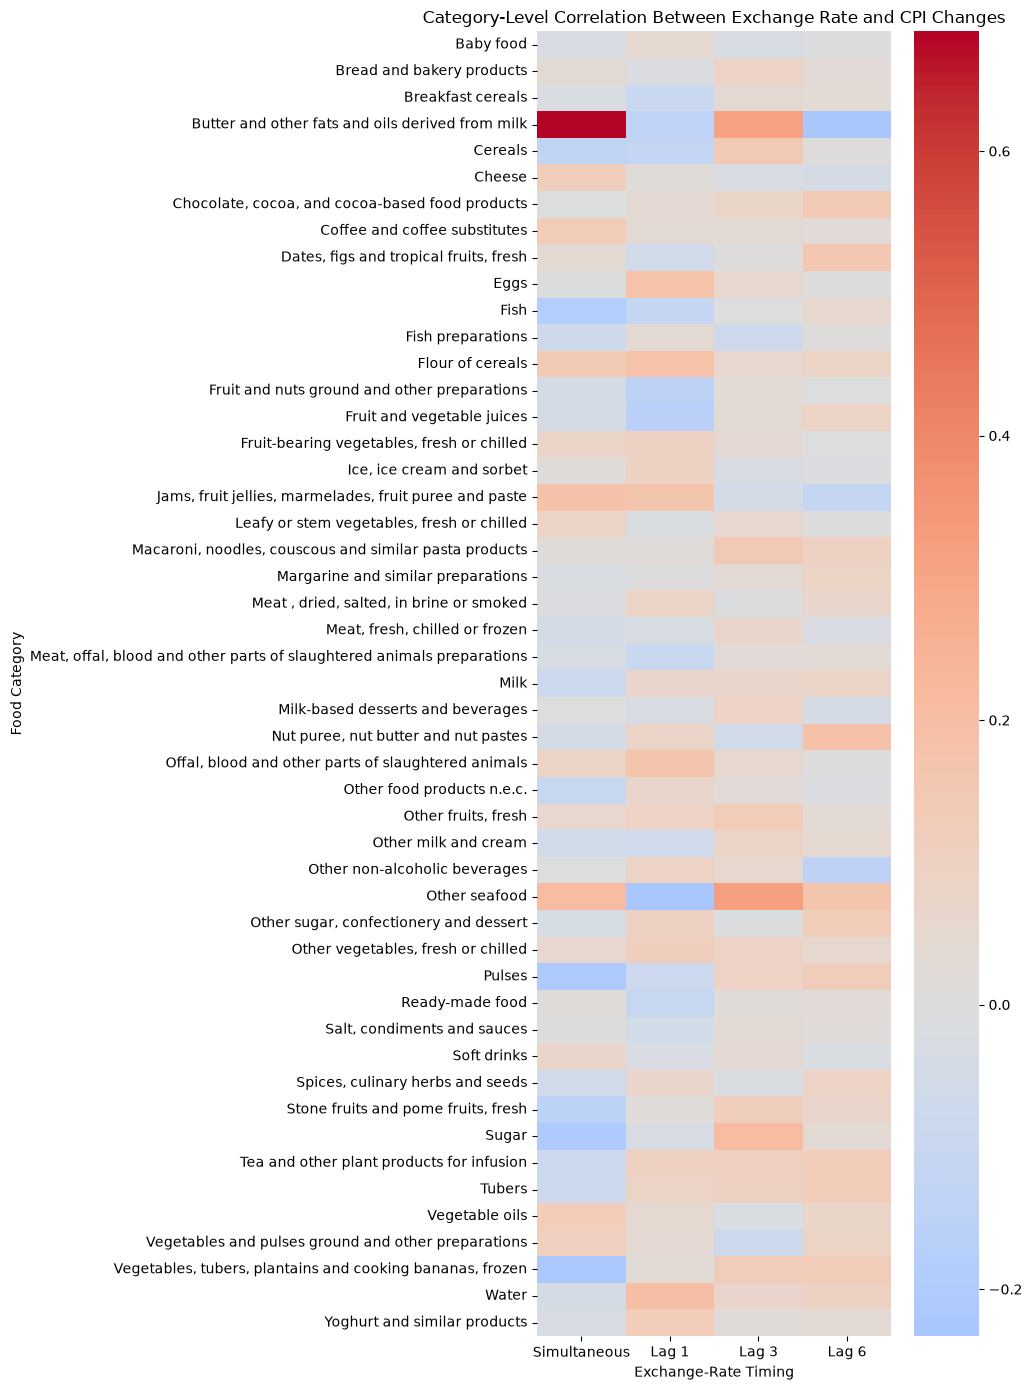

In [966]:
import seaborn as sns

plt.figure(figsize=(10,14))

sns.heatmap(
    category_lag_correlations,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Category-Level Correlation Between Exchange Rate and CPI Changes")
plt.xlabel("Exchange-Rate Timing")
plt.ylabel("Food Category")

plt.tight_layout()
plt.show()

### Heatmap Analysis

The heatmap shows that the direction and timing of the correlations differ across food subclasses. However, most correlations remain relatively weak, and no single lag structure produces consistently strong relationships across all subclasses.

Some isolated correlations appear stronger, particularly among subclasses with short histories. These estimates should be interpreted cautiously because small samples can produce unstable correlation coefficients.

The observed variation supports the use of category-specific and dynamic modelling methods in the subsequent analysis rather than relying on aggregate contemporaneous correlations alone.

In [967]:
# Visualise selected category-level relationships
selected_categories = [
    "Butter and other fats and oils derived from milk",
    "Cereals",
    "Sugar"
]

selected_data = eda_relationship[
    eda_relationship["SubclassDescription"].isin(selected_categories)
].copy()

selected_data.head()

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,...,Depreciation,Appreciation,ExchangeRate_MA3,ExchangeRate_STD3,CPI_Change,CPI_Change_Pct,ExchangeRate_Change_Pct,ExchangeRate_Change_Lag1_Pct,ExchangeRate_Change_Lag3_Pct,ExchangeRate_Change_Lag6_Pct
0,2015-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,57.2,12.452687,2015,...,0.012163,0.000000,12.241892,0.247116,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.3,12.914595,2015,...,0.037093,0.000000,12.556777,0.318784,0.036713,3.671329,3.709304,NaN,NaN,NaN
2,2015-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,13.610852,2015,...,0.053912,0.000000,12.992711,0.583021,-0.006745,-0.674536,5.391244,3.709304,NaN,NaN
3,2015-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,59.5,13.504323,2015,...,0.000000,0.007827,13.343257,0.375034,0.010187,1.018676,-0.782682,5.391244,NaN,NaN
4,2015-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,58.9,14.125733,2015,...,0.046016,0.000000,13.746969,0.332316,-0.010084,-1.008403,4.601568,-0.782682,3.709304,NaN


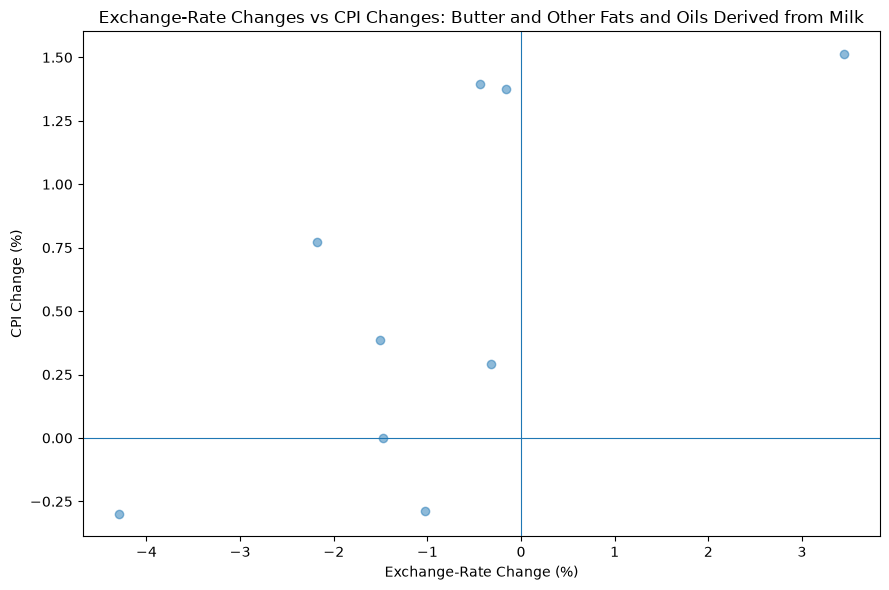

In [968]:
# Plot butter, fats and oils
butter_data = selected_data[
    selected_data["SubclassDescription"] ==
    "Butter and other fats and oils derived from milk"
]

plt.figure(figsize=(9, 6))

plt.scatter(
    butter_data["ExchangeRate_Change_Pct"],
    butter_data["CPI_Change_Pct"],
    alpha=0.5
)

plt.title(
    "Exchange-Rate Changes vs CPI Changes: "
    "Butter and Other Fats and Oils Derived from Milk"
)
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

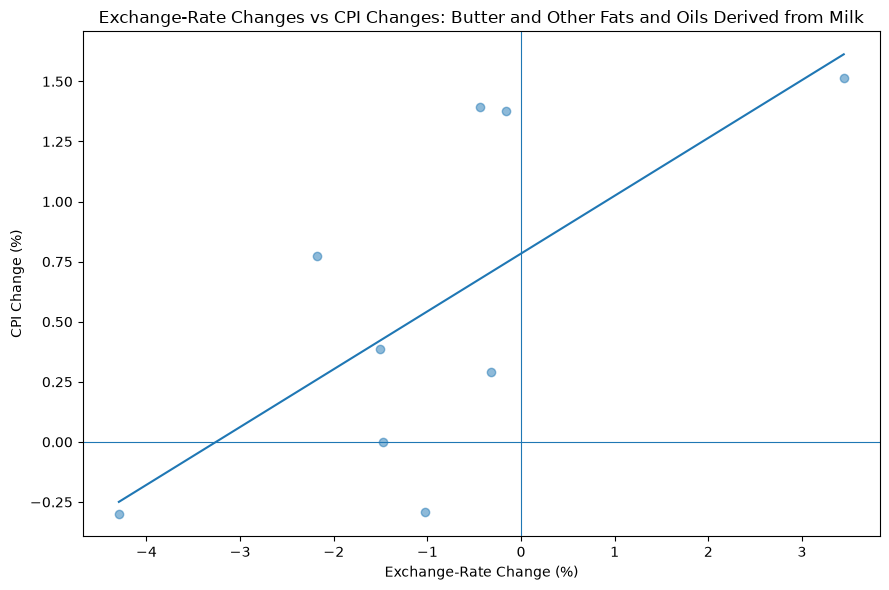

In [969]:
plt.figure(figsize=(9, 6))

plt.scatter(
    butter_data["ExchangeRate_Change_Pct"],
    butter_data["CPI_Change_Pct"],
    alpha=0.5
)

# Remove missing values
plot_data = butter_data[
    ["ExchangeRate_Change_Pct", "CPI_Change_Pct"]
].dropna()

# Calculate trend line
slope, intercept = np.polyfit(
    plot_data["ExchangeRate_Change_Pct"],
    plot_data["CPI_Change_Pct"],
    1
)

x_values = np.linspace(
    plot_data["ExchangeRate_Change_Pct"].min(),
    plot_data["ExchangeRate_Change_Pct"].max(),
    100
)

y_values = slope * x_values + intercept

plt.plot(x_values, y_values)

plt.title(
    "Exchange-Rate Changes vs CPI Changes: "
    "Butter and Other Fats and Oils Derived from Milk"
)
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

### Scatter Plot Analysis: Butter and Other Fats and Oils Derived from Milk

The scatter plot shows an upward-sloping relationship between exchange-rate changes and CPI changes.

However, the correlation of 0.684 is based on only nine usable item-month observations. The slope is therefore highly sensitive to individual observations and cannot be treated as evidence of a stable relationship.

This result is retained as a descriptive observation but is excluded from the main econometric and machine learning comparison because the subclass does not have sufficient historical coverage.

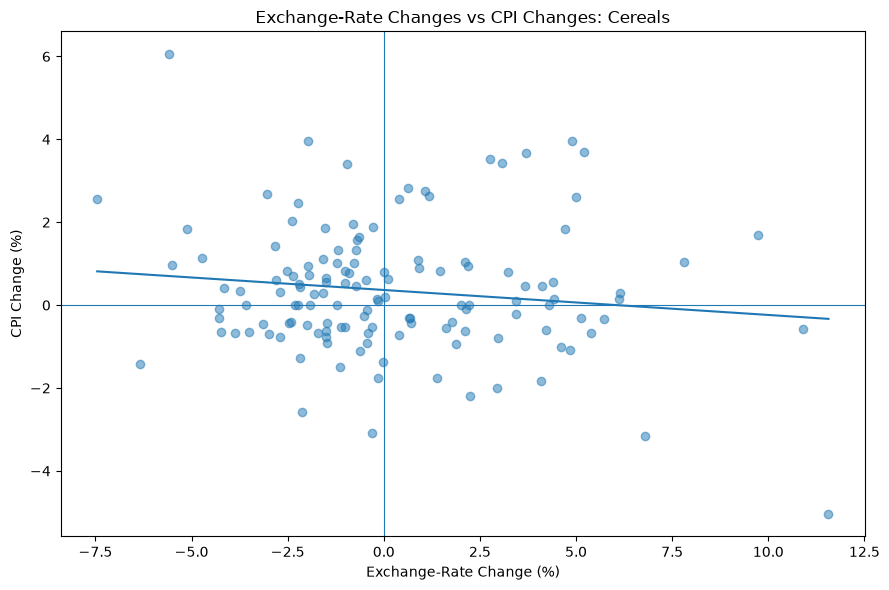

In [970]:
# Plot Cereals
cereals_data = selected_data[
    selected_data["SubclassDescription"] == "Cereals"
]

plt.figure(figsize=(9, 6))

plt.scatter(
    cereals_data["ExchangeRate_Change_Pct"],
    cereals_data["CPI_Change_Pct"],
    alpha=0.5
)

plot_data = cereals_data[
    ["ExchangeRate_Change_Pct", "CPI_Change_Pct"]
].dropna()

slope, intercept = np.polyfit(
    plot_data["ExchangeRate_Change_Pct"],
    plot_data["CPI_Change_Pct"],
    1
)

x_values = np.linspace(
    plot_data["ExchangeRate_Change_Pct"].min(),
    plot_data["ExchangeRate_Change_Pct"].max(),
    100
)

plt.plot(
    x_values,
    slope * x_values + intercept
)

plt.title("Exchange-Rate Changes vs CPI Changes: Cereals")
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

### Scatter plot Analysis: Cereals
Exchange rate changes and CPI changes have a weak tendency to move in opposite directions.

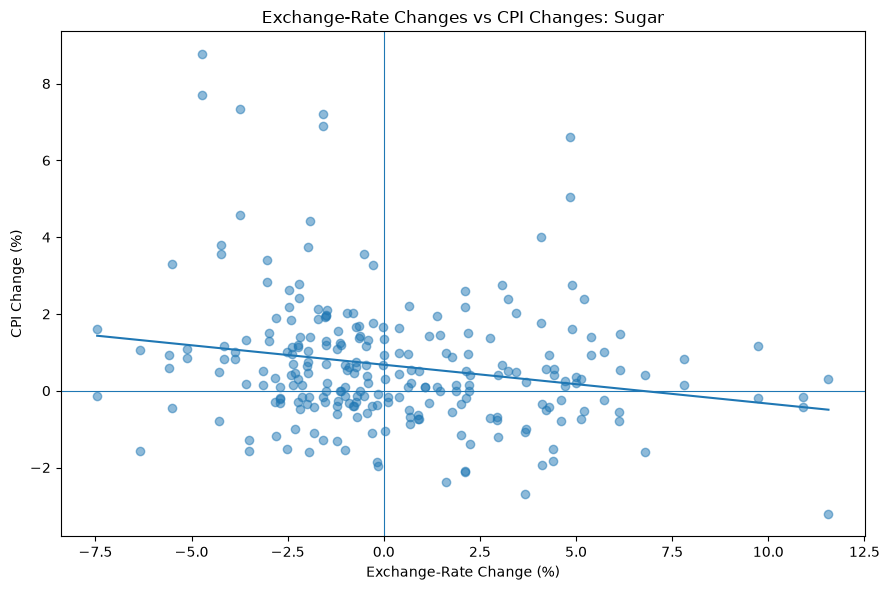

In [971]:
# Plot Sugar
sugar_data = selected_data[
    selected_data["SubclassDescription"] == "Sugar"
]

plt.figure(figsize=(9, 6))

plt.scatter(
    sugar_data["ExchangeRate_Change_Pct"],
    sugar_data["CPI_Change_Pct"],
    alpha=0.5
)

plot_data = sugar_data[
    ["ExchangeRate_Change_Pct", "CPI_Change_Pct"]
].dropna()

slope, intercept = np.polyfit(
    plot_data["ExchangeRate_Change_Pct"],
    plot_data["CPI_Change_Pct"],
    1
)

x_values = np.linspace(
    plot_data["ExchangeRate_Change_Pct"].min(),
    plot_data["ExchangeRate_Change_Pct"].max(),
    100
)

plt.plot(
    x_values,
    slope * x_values + intercept
)

plt.title("Exchange-Rate Changes vs CPI Changes: Sugar")
plt.xlabel("Exchange-Rate Change (%)")
plt.ylabel("CPI Change (%)")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

### Visual Analysis of Selected Subclass Relationships

Scatter plots with linear trend lines were used to examine the relationship between monthly exchange-rate changes and food CPI changes for selected subclasses.

Butter and other fats and oils derived from milk showed an upward-sloping trend and a correlation of 0.684. However, this result is based on only nine usable observations and is not considered reliable.

Cereals showed a weak negative correlation of -0.132 across 134 item-month observations. Sugar also showed a weak negative correlation of -0.207 across 250 item-month observations.

The plots illustrate that the observed direction of the relationship differs across food subclasses. However, the relationships are descriptive, and their reliability depends on the available sample size. They do not establish causality or quantify exchange-rate pass-through.

In [972]:
# depreciation and appreciation
eda_relationship["Depreciation"] = (
    eda_relationship["ExchangeRate_Change_Pct"] > 0
).astype(int)

eda_relationship["Appreciation"] = (
    eda_relationship["ExchangeRate_Change_Pct"] < 0
).astype(int)

In [973]:
eda_relationship[
    [
        "Date",
        "ExchangeRate_Change_Pct",
        "Depreciation",
        "Appreciation"
    ]
].head(15)

,Date,ExchangeRate_Change_Pct,Depreciation,Appreciation
0,2015-07-01,NaN,0,0
1,2015-08-01,3.709304,1,0
2,2015-09-01,5.391244,1,0
3,2015-10-01,-0.782682,0,1
4,2015-11-01,4.601568,1,0
5,2015-12-01,5.737148,1,0
6,2016-01-01,9.727926,1,0
7,2016-02-01,-3.749532,0,1
8,2016-03-01,-2.206296,0,1
9,2016-04-01,-5.114194,0,1


In [974]:
# depreciation and appreciation magnitudes
eda_relationship["Depreciation_Change"] = (
    eda_relationship["ExchangeRate_Change_Pct"]
    .where(eda_relationship["ExchangeRate_Change_Pct"] > 0, 0)
)

eda_relationship["Appreciation_Change"] = (
    eda_relationship["ExchangeRate_Change_Pct"]
    .where(eda_relationship["ExchangeRate_Change_Pct"] < 0, 0)
)

In [975]:
eda_relationship[
    [
        "Date",
        "ExchangeRate_Change_Pct",
        "Depreciation_Change",
        "Appreciation_Change"
    ]
].head(15)

,Date,ExchangeRate_Change_Pct,Depreciation_Change,Appreciation_Change
0,2015-07-01,NaN,0.000000,0.000000
1,2015-08-01,3.709304,3.709304,0.000000
2,2015-09-01,5.391244,5.391244,0.000000
3,2015-10-01,-0.782682,0.000000,-0.782682
4,2015-11-01,4.601568,4.601568,0.000000
5,2015-12-01,5.737148,5.737148,0.000000
6,2016-01-01,9.727926,9.727926,0.000000
7,2016-02-01,-3.749532,0.000000,-3.749532
8,2016-03-01,-2.206296,0.000000,-2.206296
9,2016-04-01,-5.114194,0.000000,-5.114194


In [976]:
# average CPI
asymmetry_summary = (
    eda_relationship
    .groupby("SubclassDescription")
    .agg(
        Mean_CPI_During_Depreciation=(
            "CPI_Change_Pct",
            lambda x: x[
                eda_relationship.loc[x.index, "Depreciation"] == 1
            ].mean()
        ),
        Mean_CPI_During_Appreciation=(
            "CPI_Change_Pct",
            lambda x: x[
                eda_relationship.loc[x.index, "Appreciation"] == 1
            ].mean()
        )
    )
)

In [977]:
asymmetry_summary.head(10)

,Mean_CPI_During_Depreciation,Mean_CPI_During_Appreciation
SubclassDescription,,
Baby food,0.428710,0.355035
Bread and bakery products,0.531732,0.547038
Breakfast cereals,0.387295,0.417266
Butter and other fats and oils derived from milk,1.512097,0.454049
Cereals,0.342158,0.358533
Cheese,0.595012,0.477765
"Chocolate, cocoa, and cocoa-based food products",0.557831,0.684704
Coffee and coffee substitutes,0.636654,0.689595
"Dates, figs and tropical fruits, fresh",1.237371,0.425481


In [978]:
# asymmetry column
asymmetry_summary["Asymmetry_Difference"] = (
    asymmetry_summary["Mean_CPI_During_Depreciation"]
    - asymmetry_summary["Mean_CPI_During_Appreciation"]
)

In [979]:
# sort positive difference from large to small
asymmetry_summary.sort_values(
    "Asymmetry_Difference",
    ascending=False
).head(10)

,Mean_CPI_During_Depreciation,Mean_CPI_During_Appreciation,Asymmetry_Difference
SubclassDescription,,,
Butter and other fats and oils derived from milk,1.512097,0.454049,1.058048
"Dates, figs and tropical fruits, fresh",1.237371,0.425481,0.811889
"Fruit-bearing vegetables, fresh or chilled",1.137732,0.414140,0.723592
"Other vegetables, fresh or chilled",0.840230,0.270310,0.569920
"Jams, fruit jellies, marmelades, fruit puree and paste",0.841601,0.347123,0.494478
"Leafy or stem vegetables, fresh or chilled",0.680978,0.396372,0.284606
"Offal, blood and other parts of slaughtered animals",0.755195,0.519787,0.235408
Vegetables and pulses ground and other preparations,0.622953,0.407286,0.215667
Cheese,0.595012,0.477765,0.117247


In [980]:
# sort negative difference from large to small
asymmetry_summary.sort_values(
    "Asymmetry_Difference",
    ascending=True
).head(10)

,Mean_CPI_During_Depreciation,Mean_CPI_During_Appreciation,Asymmetry_Difference
SubclassDescription,,,
Tubers,0.261932,0.924923,-0.662991
Sugar,0.275747,0.928907,-0.653160
"Vegetables, tubers, plantains and cooking bananas, frozen",-0.016329,0.629343,-0.645672
Pulses,0.337193,0.787029,-0.449836
"Stone fruits and pome fruits, fresh",0.277758,0.676043,-0.398286
Tea and other plant products for infusion,0.457030,0.833418,-0.376388
Milk-based desserts and beverages,0.153745,0.497453,-0.343707
"Macaroni, noodles, couscous and similar pasta products",0.263622,0.586232,-0.322610
Other food products n.e.c.,0.352782,0.670016,-0.317234


### Analysis on Descriptive Asymmetry

Not all food categories demonstrated higher average CPI changes during Rand depreciation periods. Several categories showed negative asymmetry differences, indicating that their average CPI changes were higher during periods of Rand appreciation.

For example, tubers recorded an average CPI change of 0.262% during depreciation months and 0.925% during appreciation months, resulting in an asymmetry difference of -0.663 percentage points. Sugar showed a similar pattern, with an asymmetry difference of -0.653 percentage points. Frozen vegetables, tubers, plantains and cooking bananas recorded an asymmetry difference of -0.646 percentage points.

These findings further demonstrate the heterogeneous nature of the relationship between exchange-rate movements and food prices. The direction of the descriptive asymmetry is not uniform across food categories.

In [981]:
# compare CPI with depreciation and appreciation magnitude
depreciation_correlations = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Depreciation_Change"]
        )
    )
    .sort_values(ascending=False)
)

appreciation_correlations = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Appreciation_Change"]
        )
    )
    .sort_values(ascending=False)
)

In [982]:
print("Strongest depreciation relationships:")
print(depreciation_correlations.head(10))

print("\nStrongest appreciation relationships:")
print(appreciation_correlations.head(10))

Strongest depreciation relationships:
SubclassDescription
Butter and other fats and oils derived from milk          0.487621
Jams, fruit jellies, marmelades, fruit puree and paste    0.253019
Flour of cereals                                          0.168171
Vegetable oils                                            0.166433
Coffee and coffee substitutes                             0.132195
Cheese                                                    0.127616
Offal, blood and other parts of slaughtered animals       0.121875
Leafy or stem vegetables, fresh or chilled                0.117424
Other vegetables, fresh or chilled                        0.106412
Soft drinks                                               0.095759
dtype: float64

Strongest appreciation relationships:
SubclassDescription
Butter and other fats and oils derived from milk       0.627602
Other seafood                                          0.314421
Vegetables and pulses ground and other preparations    0.122478
Other 

In [983]:
eda_relationship["Depreciation_Magnitude"] = (
    eda_relationship["Depreciation_Change"].abs()
)

eda_relationship["Appreciation_Magnitude"] = (
    eda_relationship["Appreciation_Change"].abs()
)

In [984]:
depreciation_magnitude_corr = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Depreciation_Magnitude"]
        )
    )
    .sort_values(ascending=False)
)

appreciation_magnitude_corr = (
    eda_relationship
    .groupby("SubclassDescription")
    .apply(
        lambda x: x["CPI_Change_Pct"].corr(
            x["Appreciation_Magnitude"]
        )
    )
    .sort_values(ascending=False)
)

In [985]:
print("Strongest depreciation magnitude relationships:")
print(depreciation_magnitude_corr.head(10))

print("\nStrongest appreciation magnitude relationships:")
print(appreciation_magnitude_corr.head(10))

Strongest depreciation magnitude relationships:
SubclassDescription
Butter and other fats and oils derived from milk          0.487621
Jams, fruit jellies, marmelades, fruit puree and paste    0.253019
Flour of cereals                                          0.168171
Vegetable oils                                            0.166433
Coffee and coffee substitutes                             0.132195
Cheese                                                    0.127616
Offal, blood and other parts of slaughtered animals       0.121875
Leafy or stem vegetables, fresh or chilled                0.117424
Other vegetables, fresh or chilled                        0.106412
Soft drinks                                               0.095759
dtype: float64

Strongest appreciation magnitude relationships:
SubclassDescription
Pulses                                                       0.327567
Sugar                                                        0.235233
Vegetables, tubers, plantains and cook

In [986]:
asymmetry_corr = pd.concat(
    [
        depreciation_magnitude_corr.rename(
            "Depreciation_Correlation"
        ),
        appreciation_magnitude_corr.rename(
            "Appreciation_Correlation"
        )
    ],
    axis=1
)

asymmetry_corr["Difference"] = (
    asymmetry_corr["Depreciation_Correlation"]
    - asymmetry_corr["Appreciation_Correlation"]
)

asymmetry_corr.sort_values(
    "Difference",
    ascending=False
).head(10)

,Depreciation_Correlation,Appreciation_Correlation,Difference
SubclassDescription,,,
Butter and other fats and oils derived from milk,0.487621,-0.627602,1.115222
Other seafood,0.010050,-0.314421,0.324472
"Jams, fruit jellies, marmelades, fruit puree and paste",0.253019,-0.006355,0.259373
Coffee and coffee substitutes,0.132195,-0.084213,0.216409
Flour of cereals,0.168171,-0.035305,0.203476
Vegetables and pulses ground and other preparations,0.078070,-0.122478,0.200548
Cheese,0.127616,-0.052227,0.179842
Vegetable oils,0.166433,-0.011736,0.178169
"Fruit-bearing vegetables, fresh or chilled",0.082137,-0.042340,0.124477


In [987]:
asymmetry_corr.sort_values(
    "Difference",
    ascending=True
).head(10)

,Depreciation_Correlation,Appreciation_Correlation,Difference
SubclassDescription,,,
Pulses,-0.081828,0.327567,-0.409395
Sugar,-0.141444,0.235233,-0.376677
"Vegetables, tubers, plantains and cooking bananas, frozen",-0.210042,0.160986,-0.371029
Fish,-0.163975,0.141566,-0.305540
Cereals,-0.112359,0.115645,-0.228003
"Stone fruits and pome fruits, fresh",-0.190143,0.034895,-0.225037
Other food products n.e.c.,-0.086665,0.087484,-0.174149
Tea and other plant products for infusion,-0.062433,0.093352,-0.155785
Fish preparations,-0.020345,0.128706,-0.149051


### Depreciation and Appreciation Magnitude Relationships

Exchange-rate changes were separated into depreciation and appreciation magnitudes to examine possible descriptive asymmetry within food subclasses.

Butter and other fats and oils derived from milk recorded a depreciation-magnitude correlation of 0.488 and an appreciation-magnitude correlation of -0.628. However, these results are based on only nine usable observations and should not be interpreted as reliable evidence of asymmetric pass-through.

Other subclasses also showed different relationships across exchange-rate directions. Pulses recorded correlations of -0.082 during depreciation and 0.328 during appreciation, while sugar recorded correlations of -0.141 and 0.235 respectively.

These findings provide preliminary descriptive evidence of heterogeneous and potentially asymmetric relationships. Formal conclusions about asymmetry will depend on the NARDL and machine learning results using categories with sufficient historical coverage.

In [988]:
# inspect the final dataset
eda_relationship.shape

(14150, 32)

In [989]:
eda_relationship.columns.tolist()

['Date',
 'DivisionDescription',
 'GroupDescription',
 'ClassDescription',
 'SubclassDescription',
 'Weight',
 'Eight digit code',
 'CPI',
 'ExchangeRate',
 'Year',
 'Month',
 'Quarter',
 'ExchangeRate_Lag1',
 'ExchangeRate_Lag3',
 'ExchangeRate_Lag6',
 'CPI_Lag1',
 'CPI_Lag3',
 'ExchangeRate_Change',
 'Depreciation',
 'Appreciation',
 'ExchangeRate_MA3',
 'ExchangeRate_STD3',
 'CPI_Change',
 'CPI_Change_Pct',
 'ExchangeRate_Change_Pct',
 'ExchangeRate_Change_Lag1_Pct',
 'ExchangeRate_Change_Lag3_Pct',
 'ExchangeRate_Change_Lag6_Pct',
 'Depreciation_Change',
 'Appreciation_Change',
 'Depreciation_Magnitude',
 'Appreciation_Magnitude']

In [990]:
eda_relationship.isna().sum()

Date                              0
DivisionDescription               0
GroupDescription                  0
ClassDescription                  0
SubclassDescription               0
Weight                            0
Eight digit code                  0
CPI                               0
ExchangeRate                      0
Year                              0
Month                             0
Quarter                           0
ExchangeRate_Lag1                 0
ExchangeRate_Lag3                 0
ExchangeRate_Lag6                 0
CPI_Lag1                          0
CPI_Lag3                          0
ExchangeRate_Change               0
Depreciation                      0
Appreciation                      0
ExchangeRate_MA3                  0
ExchangeRate_STD3                 0
CPI_Change                      134
CPI_Change_Pct                  134
ExchangeRate_Change_Pct          95
ExchangeRate_Change_Lag1_Pct    190
ExchangeRate_Change_Lag3_Pct    380
ExchangeRate_Change_Lag6_Pct

In [991]:
# category to observations

category_counts = (
    eda_relationship
    .groupby("SubclassDescription")
    .size()
    .sort_values()
)

category_counts

SubclassDescription
Butter and other fats and oils derived from milk                            10
Other seafood                                                               10
Jams, fruit jellies, marmelades, fruit puree and paste                      55
Eggs                                                                       126
Nut puree, nut butter and nut pastes                                       126
Other fruits, fresh                                                        126
Ice, ice cream and sorbet                                                  126
Dates, figs and tropical fruits, fresh                                     126
Stone fruits and pome fruits, fresh                                        126
Water                                                                      126
Pulses                                                                     126
Vegetables, tubers, plantains and cooking bananas, frozen                  126
Other non-alcoholic beverages   

In [992]:
category_counts.describe()

count      49.000000
mean      288.775510
std       204.253138
min        10.000000
25%       126.000000
50%       252.000000
75%       378.000000
max      1029.000000
dtype: float64

In [993]:
# ckeck duplicate category-date observations
duplicates = eda_relationship[
    eda_relationship.duplicated(
        subset=["Date", "SubclassDescription"],
        keep=False
    )
]

duplicates.shape

(12322, 32)

In [994]:
print("Number of duplicate rows:", len(duplicates))

Number of duplicate rows: 12322


In [995]:
duplicates.head(20)

,Date,DivisionDescription,GroupDescription,ClassDescription,SubclassDescription,Weight,Eight digit code,CPI,ExchangeRate,Year,...,CPI_Change,CPI_Change_Pct,ExchangeRate_Change_Pct,ExchangeRate_Change_Lag1_Pct,ExchangeRate_Change_Lag3_Pct,ExchangeRate_Change_Lag6_Pct,Depreciation_Change,Appreciation_Change,Depreciation_Magnitude,Appreciation_Magnitude
116,2025-03-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,98.7,18.285360,2025,...,-0.014970,-1.497006,-1.146270,-1.213670,1.380821,-2.219353,0.000000,-1.146270,0.000000,1.146270
117,2025-04-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,98.8,18.915474,2025,...,0.001013,0.101317,3.446001,-1.146270,2.979005,-0.400409,3.446001,0.000000,3.446001,0.000000
118,2025-05-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,98.7,18.103133,2025,...,-0.001012,-0.101215,-4.294581,3.446001,-1.213670,2.132194,0.000000,-4.294581,0.000000,4.294581
119,2025-06-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,97.8,17.836520,2025,...,-0.009119,-0.911854,-1.472747,-4.294581,-1.146270,1.380821,0.000000,-1.472747,0.000000,1.472747
120,2025-07-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,96.9,17.759252,2025,...,-0.009202,-0.920245,-0.433200,-1.472747,3.446001,2.979005,0.000000,-0.433200,0.000000,0.433200
121,2025-08-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,95.2,17.731210,2025,...,-0.017544,-1.754386,-0.157904,-0.433200,-4.294581,-1.213670,0.000000,-0.157904,0.000000,0.157904
122,2025-09-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,94.6,17.463381,2025,...,-0.006303,-0.630252,-1.510492,-0.157904,-1.472747,-1.146270,0.000000,-1.510492,0.000000,1.510492
123,2025-10-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,94.1,17.285200,2025,...,-0.005285,-0.528541,-1.020312,-1.510492,-0.433200,3.446001,0.000000,-1.020312,0.000000,1.020312
124,2025-11-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,91.2,17.230220,2025,...,-0.030818,-3.081828,-0.318076,-1.020312,-0.157904,-4.294581,0.000000,-0.318076,0.000000,0.318076
125,2025-12-01,Food and non-alcoholic beverages,Food,Cereal products,Cereals,0.540243,1111201,91.6,16.855665,2025,...,0.004386,0.438596,-2.173826,-0.318076,-1.510492,-1.472747,0.000000,-2.173826,0.000000,2.173826


In [996]:
# date frequency
eda_relationship["Date"].sort_values().unique()[:10]

<DatetimeArray>
['2015-07-01 00:00:00', '2015-08-01 00:00:00', '2015-09-01 00:00:00',
 '2015-10-01 00:00:00', '2015-11-01 00:00:00', '2015-12-01 00:00:00',
 '2016-01-01 00:00:00', '2016-02-01 00:00:00', '2016-03-01 00:00:00',
 '2016-04-01 00:00:00']
Length: 10, dtype: datetime64[us]

In [997]:
eda_relationship["Date"].sort_values().unique()[-10:]

<DatetimeArray>
['2025-03-01 00:00:00', '2025-04-01 00:00:00', '2025-05-01 00:00:00',
 '2025-06-01 00:00:00', '2025-07-01 00:00:00', '2025-08-01 00:00:00',
 '2025-09-01 00:00:00', '2025-10-01 00:00:00', '2025-11-01 00:00:00',
 '2025-12-01 00:00:00']
Length: 10, dtype: datetime64[us]

In [998]:
eda_relationship["Date"].nunique()

126

In [999]:
# inspect duplicates
duplicates[
    ["Date", "SubclassDescription", "Eight digit code", "CPI"]
].head(30)

,Date,SubclassDescription,Eight digit code,CPI
116,2025-03-01,Cereals,1111201,98.7
117,2025-04-01,Cereals,1111201,98.8
118,2025-05-01,Cereals,1111201,98.7
119,2025-06-01,Cereals,1111201,97.8
120,2025-07-01,Cereals,1111201,96.9
121,2025-08-01,Cereals,1111201,95.2
122,2025-09-01,Cereals,1111201,94.6
123,2025-10-01,Cereals,1111201,94.1
124,2025-11-01,Cereals,1111201,91.2
125,2025-12-01,Cereals,1111201,91.6


In [1000]:
duplicates["SubclassDescription"].value_counts().head(20)

SubclassDescription
Meat, fresh, chilled or frozen                                            1029
Bread and bakery products                                                  840
Salt, condiments and sauces                                                756
Meat, offal, blood and other parts of slaughtered animals preparations     523
Cheese                                                                     514
Other vegetables, fresh or chilled                                         514
Milk                                                                       504
Fruit-bearing vegetables, fresh or chilled                                 504
Other food products n.e.c.                                                 504
Meat , dried, salted, in brine or smoked                                   378
Fish                                                                       378
Yoghurt and similar products                                               378
Leafy or stem vegetables, fresh 

In [1001]:
duplicates[
    ["Date", "SubclassDescription"]
].value_counts().head(20)

Date        SubclassDescription           
2017-04-01  Meat, fresh, chilled or frozen    9
2017-05-01  Meat, fresh, chilled or frozen    9
2017-06-01  Meat, fresh, chilled or frozen    9
2017-07-01  Meat, fresh, chilled or frozen    9
2017-08-01  Meat, fresh, chilled or frozen    9
2017-09-01  Meat, fresh, chilled or frozen    9
2017-10-01  Meat, fresh, chilled or frozen    9
2017-11-01  Meat, fresh, chilled or frozen    9
2017-12-01  Meat, fresh, chilled or frozen    9
2018-01-01  Meat, fresh, chilled or frozen    9
2018-02-01  Meat, fresh, chilled or frozen    9
2018-03-01  Meat, fresh, chilled or frozen    9
2018-04-01  Meat, fresh, chilled or frozen    9
2018-05-01  Meat, fresh, chilled or frozen    9
2018-06-01  Meat, fresh, chilled or frozen    9
2018-07-01  Meat, fresh, chilled or frozen    9
2018-08-01  Meat, fresh, chilled or frozen    9
2018-09-01  Meat, fresh, chilled or frozen    9
2018-10-01  Meat, fresh, chilled or frozen    9
2018-11-01  Meat, fresh, chilled or frozen   

In [1002]:
# re-run duplicate check
duplicates_correct = eda_relationship[
    eda_relationship.duplicated(
        subset=["Date", "SubclassDescription", "Eight digit code"],
        keep=False
    )
]

print("Number of true duplicate rows:", len(duplicates_correct))

Number of true duplicate rows: 0


In [1003]:
# save the dataset
eda_relationship.to_csv(
    "../data/processed/eda_relationship.csv",
    index=False
)

print("Save is successful!")

Save is successful!


### Conclusion of Exploratory Data Analysis

The exploratory analysis examined exchange-rate movements and disaggregated food CPI changes from 2015 to 2025. The analysis identified substantial variation in CPI changes across food categories and found that the contemporaneous correlation between exchange-rate changes and food CPI changes was very weak. Lagged correlations were also generally weak, although certain food categories showed stronger relationships at specific lags.

Exchange-rate movements were subsequently separated into depreciation and appreciation periods and analysed using both directional indicators and movement magnitudes. The results showed considerable heterogeneity across food categories. Some categories demonstrated stronger associations during periods of Rand depreciation, while others showed stronger associations during appreciation.

Subclasses with very short histories produced potentially unstable correlations and were therefore retained for descriptive analysis but excluded from the main econometric and machine learning comparison.

Finally, the modelling dataset was verified for structural consistency. Duplicate observations were assessed using Date, SubclassDescription and Eight digit code as the observation identifiers, with no true duplicates identified.